In [42]:
import pandas as pd

In [43]:
df = pd.read_csv('fraud.csv')

In [44]:
df.head()

,transaction_amount,hour_of_day,is_weekend,num_items,customer_age,prev_transactions,distance_from_home,device_type,network_quality,is_first_transaction,store_type,velocity_score,is_fraud
0,161.363691,3.0,0.0,2.0,18.000000,2.0,26.539742,1.0,48.403937,0.0,0.0,3.718296,0
1,116.202851,1.0,1.0,4.0,26.285818,2.0,50.714402,NaN,76.144979,0.0,0.0,4.951272,0
2,1.000000,2.0,0.0,5.0,18.000000,NaN,9.467935,0.0,67.600316,0.0,0.0,4.556043,0
3,48.780618,2.0,0.0,3.0,44.471190,NaN,41.077068,0.0,94.825526,0.0,0.0,6.918437,0
4,NaN,3.0,0.0,4.0,38.733609,8.0,NaN,2.0,100.000000,0.0,1.0,5.535335,1


In [45]:
df['device_name'] = df['device_type'].map({0: 'Mobile', 1: 'Desktop', 2: 'Tablet'})

In [46]:
df[['device_type', 'device_name']].head()

,device_type,device_name
0,1.0,Desktop
1,NaN,NaN
2,0.0,Mobile
3,0.0,Mobile
4,2.0,Tablet


In [47]:
df['weekend_status'] = df['is_weekend'].map({0: 'Weekday', 1: 'Weekend'})

In [48]:
df[['is_weekend', 'weekend_status']].head()

,is_weekend,weekend_status
0,0.0,Weekday
1,1.0,Weekend
2,0.0,Weekday
3,0.0,Weekday
4,0.0,Weekday


In [49]:
df['first_time_buyer'] = df['is_first_transaction'].map({0: 'Returning', 1: 'First Time'})

In [50]:
import pandas as pd

df = pd.read_csv('fraud.csv')
df.head()

,transaction_amount,hour_of_day,is_weekend,num_items,customer_age,prev_transactions,distance_from_home,device_type,network_quality,is_first_transaction,store_type,velocity_score,is_fraud
0,161.363691,3.0,0.0,2.0,18.000000,2.0,26.539742,1.0,48.403937,0.0,0.0,3.718296,0
1,116.202851,1.0,1.0,4.0,26.285818,2.0,50.714402,NaN,76.144979,0.0,0.0,4.951272,0
2,1.000000,2.0,0.0,5.0,18.000000,NaN,9.467935,0.0,67.600316,0.0,0.0,4.556043,0
3,48.780618,2.0,0.0,3.0,44.471190,NaN,41.077068,0.0,94.825526,0.0,0.0,6.918437,0
4,NaN,3.0,0.0,4.0,38.733609,8.0,NaN,2.0,100.000000,0.0,1.0,5.535335,1


In [51]:
# Missing percentage per column
missing_perc = df.isnull().mean() * 100
missing_perc.sort_values(ascending=False)

velocity_score          15.0
customer_age            12.0
distance_from_home      10.0
network_quality          9.0
transaction_amount       8.0
prev_transactions        7.0
hour_of_day              5.0
device_type              4.0
num_items                3.0
is_first_transaction     3.0
is_weekend               2.0
store_type               2.0
is_fraud                 0.0
dtype: float64

In [52]:
# Data Cleaning & Quality Assessment

# Checking duplicate rows
duplicates = df.duplicated().sum()

print(f"Total Duplicate Rows: {duplicates}")

Total Duplicate Rows: 0


In [53]:
# Missing value analysis
missing_values = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': missing_values
})

missing_df.sort_values(by='Missing Percentage', ascending=False)

,Missing Count,Missing Percentage
velocity_score,1050,15.0
customer_age,840,12.0
distance_from_home,700,10.0
network_quality,630,9.0
transaction_amount,560,8.0
prev_transactions,490,7.0
hour_of_day,350,5.0
device_type,280,4.0
num_items,210,3.0
is_first_transaction,210,3.0


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   transaction_amount    6440 non-null   float64
 1   hour_of_day           6650 non-null   float64
 2   is_weekend            6860 non-null   float64
 3   num_items             6790 non-null   float64
 4   customer_age          6160 non-null   float64
 5   prev_transactions     6510 non-null   float64
 6   distance_from_home    6300 non-null   float64
 7   device_type           6720 non-null   float64
 8   network_quality       6370 non-null   float64
 9   is_first_transaction  6790 non-null   float64
 10  store_type            6860 non-null   float64
 11  velocity_score        5950 non-null   float64
 12  is_fraud              7000 non-null   int64  
dtypes: float64(12), int64(1)
memory usage: 711.1 KB


In [55]:
df['is_fraud'].value_counts()

is_fraud
0    6279
1     721
Name: count, dtype: int64

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

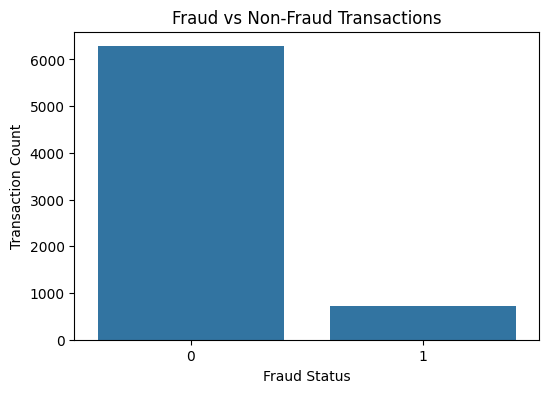

In [57]:
plt.figure(figsize=(6,4))

sns.countplot(x='is_fraud', data=df)

plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('Fraud Status')
plt.ylabel('Transaction Count')

plt.show()

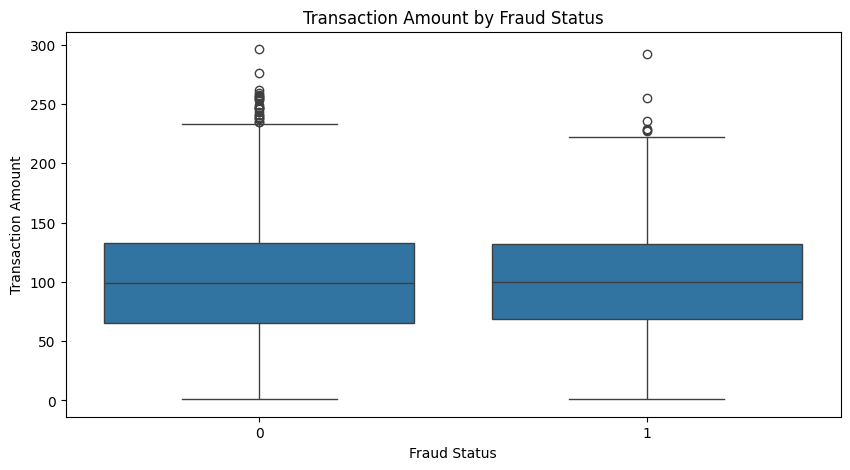

In [58]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='is_fraud',
    y='transaction_amount',
    data=df
)

plt.title('Transaction Amount by Fraud Status')
plt.xlabel('Fraud Status')
plt.ylabel('Transaction Amount')

plt.show()

In [ ]:
## Transaction Amount vs Fraud Status — Analysis

A boxplot was used to compare transaction amounts between legitimate (`0`) and fraudulent (`1`) transactions.

### Key Observations:
- Both fraudulent and legitimate transactions show similar transaction amount distributions.
- The median transaction amount is nearly the same for both groups.
- Several outliers are present in both fraud and non-fraud transactions.
- Legitimate transactions contain more outliers because the dataset contains significantly more legitimate transactions overall.

### Important Insight:
High transaction amount alone is not a strong indicator of fraud. Many legitimate customers also perform high-value transactions.

This suggests that fraud detection depends on combinations of multiple behavioral signals rather than transaction amount in isolation.

### Fraud Analytics Learning:
Outliers represent unusually high transaction amounts, but outliers are not automatically fraudulent. In fraud analytics, analysts must combine multiple variables such as:
- transaction amount,
- transaction timing,
- customer behavior,
- device type,
- and geographic patterns

to identify suspicious activity more accurately.

### Median Transaction Amount Insight
The median transaction amount for fraudulent and legitimate transactions appears very similar. This indicates that the typical spending behavior between the two groups does not differ significantly based only on transaction amount.
Therefore, transaction amount alone may not be sufficient to identify fraudulent activity accurately.

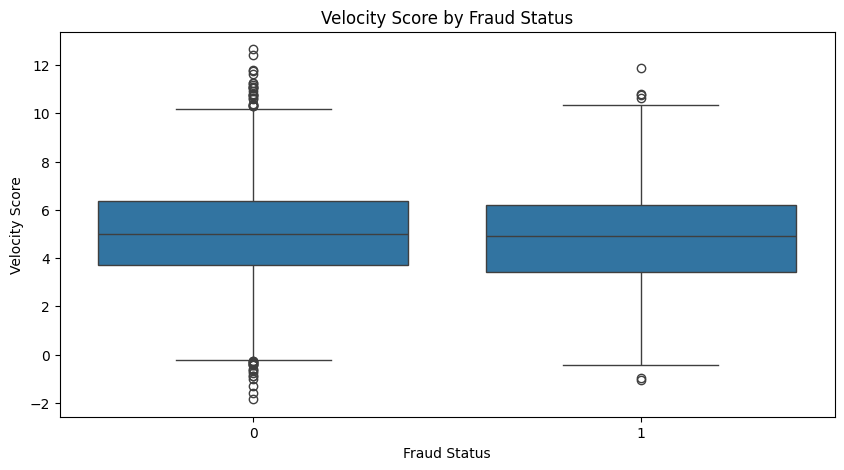

In [60]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='is_fraud',
    y='velocity_score',
    data=df
)

plt.title('Velocity Score by Fraud Status')
plt.xlabel('Fraud Status')
plt.ylabel('Velocity Score')

plt.show()

In [61]:
df_clean = df.copy()

In [68]:
df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [65]:
numerical_cols = [
    'transaction_amount',
    'hour_of_day',
    'num_items',
    'customer_age',
    'prev_transactions',
    'distance_from_home',
    'network_quality',
    'velocity_score'
]

for col in numerical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [66]:
categorical_cols = [
    'device_type',
    'is_first_transaction',
    'is_weekend',
    'store_type'
]

for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [67]:
df_clean.isnull().sum()

transaction_amount      0
hour_of_day             0
is_weekend              0
num_items               0
customer_age            0
prev_transactions       0
distance_from_home      0
device_type             0
network_quality         0
is_first_transaction    0
store_type              0
velocity_score          0
is_fraud                0
dtype: int64

In [ ]:
# Missing Value Imputation Completed

A cleaned version of the dataset (`df_clean`) was created to preserve the original raw dataset for reproducibility and comparison.

## Numerical Features
Missing values in numerical columns were imputed using the median value. Median imputation was selected because fraud-related financial data often contains outliers, and the median is more robust to extreme values than the mean.

## Categorical/Binary Features
Missing values in categorical and binary variables were imputed using the mode (most frequent value).

## Validation
After preprocessing, all missing values were successfully removed from the cleaned dataset.

This preprocessing step prepares the dataset for:
- exploratory data analysis (EDA),
- statistical analysis,
- and machine learning modeling.

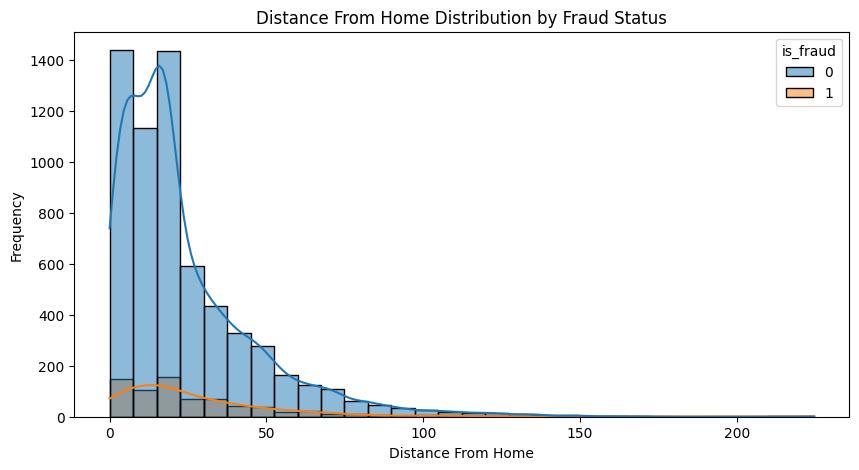

In [69]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df_clean,
    x='distance_from_home',
    hue='is_fraud',
    bins=30,
    kde=True
)

plt.title('Distance From Home Distribution by Fraud Status')
plt.xlabel('Distance From Home')
plt.ylabel('Frequency')

plt.show()

In [ ]:
## Distance From Home vs Fraud Status — Analysis

A histogram distribution plot was used to compare transaction distances between legitimate (`0`) and fraudulent (`1`) transactions.

### Key Observations:
- Most transactions occur relatively close to the customer’s home location.
- Fraudulent transactions show a wider spread toward larger distances.
- Fraud-related activity appears more common at unusually distant locations compared to legitimate transactions.
- Both fraud and non-fraud distributions are right-skewed, meaning most observations occur at shorter distances while a smaller number occur at extreme distances.

### Important Insight:
`distance_from_home` appears to provide stronger fraud-related behavioral information compared to variables such as transaction amount.

This suggests that geographic anomalies may play an important role in identifying suspicious financial activity.

### Fraud Analytics Learning:
In fraud detection systems, unusual geographic behavior is often considered a strong risk indicator, especially when transactions occur far from a customer’s normal location patterns.

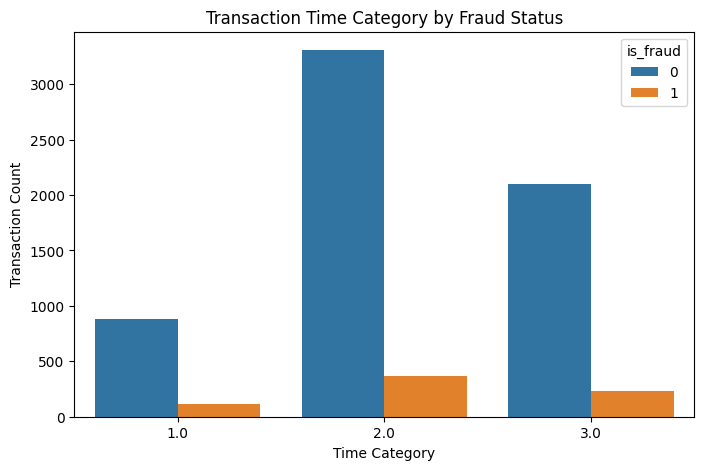

In [70]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='hour_of_day',
    hue='is_fraud',
    data=df_clean
)

plt.title('Transaction Time Category by Fraud Status')
plt.xlabel('Time Category')
plt.ylabel('Transaction Count')

plt.show()

In [ ]:
## Understanding Encoded Time Categories

The `hour_of_day` variable does not represent exact hourly values. Instead, the dataset encodes transaction time into categorical groups:

- `1` = Morning
- `2` = Afternoon
- `3` = Evening/Night

Because this variable is categorical rather than continuous, a histogram was not the most appropriate visualization choice.

A countplot was selected instead to better compare transaction frequency patterns between fraudulent and legitimate transactions across different time categories.

### Learning:
Selecting visualizations based on variable type is an important part of exploratory data analysis (EDA). Categorical variables are generally better represented using bar charts or countplots rather than histograms.

In [71]:
fraud_rate_by_time = pd.crosstab(
    df_clean['hour_of_day'],
    df_clean['is_fraud'],
    normalize='index'
) * 100

fraud_rate_by_time.round(2)

is_fraud,0,1
hour_of_day,,
1.0,88.23,11.77
2.0,89.96,10.04
3.0,89.91,10.09


In [ ]:
## Transaction Time Category vs Fraud Status — Initial Observations

A countplot was used to compare transaction frequency across encoded time categories between legitimate and fraudulent transactions.

### Key Observations:
- Time category `2` contains the highest number of transactions overall.
- Fraudulent transactions are also most frequent within category `2`.
- Legitimate transactions dominate all time categories due to the dataset imbalance.

### Important Analytical Consideration:
Higher fraud counts in a category do not necessarily indicate higher fraud risk. Categories with larger overall transaction volumes naturally produce more fraud cases.

To properly evaluate risk, fraud rates (fraud percentage within each category) should be analyzed instead of relying only on raw transaction counts.

### Fraud Analytics Learning:
Fraud analysis should focus on proportional risk rather than absolute transaction counts.

In [ ]:
## Fraud Rate by Time Category — Analysis

Fraud percentages were calculated within each time category to evaluate proportional fraud risk rather than relying on raw transaction counts.

### Fraud Rates:
| Time Category | Fraud Rate (%) |
|---|---|
| 1 | 11.77% |
| 2 | 10.04% |
| 3 | 10.09% |

### Key Observations:
- Time category `1` shows the highest fraud rate proportionally.
- Although category `2` contains the largest number of fraud transactions overall, its fraud percentage is lower due to the significantly larger transaction volume.
- Fraud rates across all categories remain relatively similar.

### Important Insight:
Raw fraud counts alone can be misleading. Fraud analysis should focus on proportional fraud risk rather than absolute transaction volume.

### Fraud Analytics Learning:
Normalization and percentage-based analysis are essential in fraud analytics because larger transaction categories naturally produce higher fraud counts even when their actual risk level is lower.

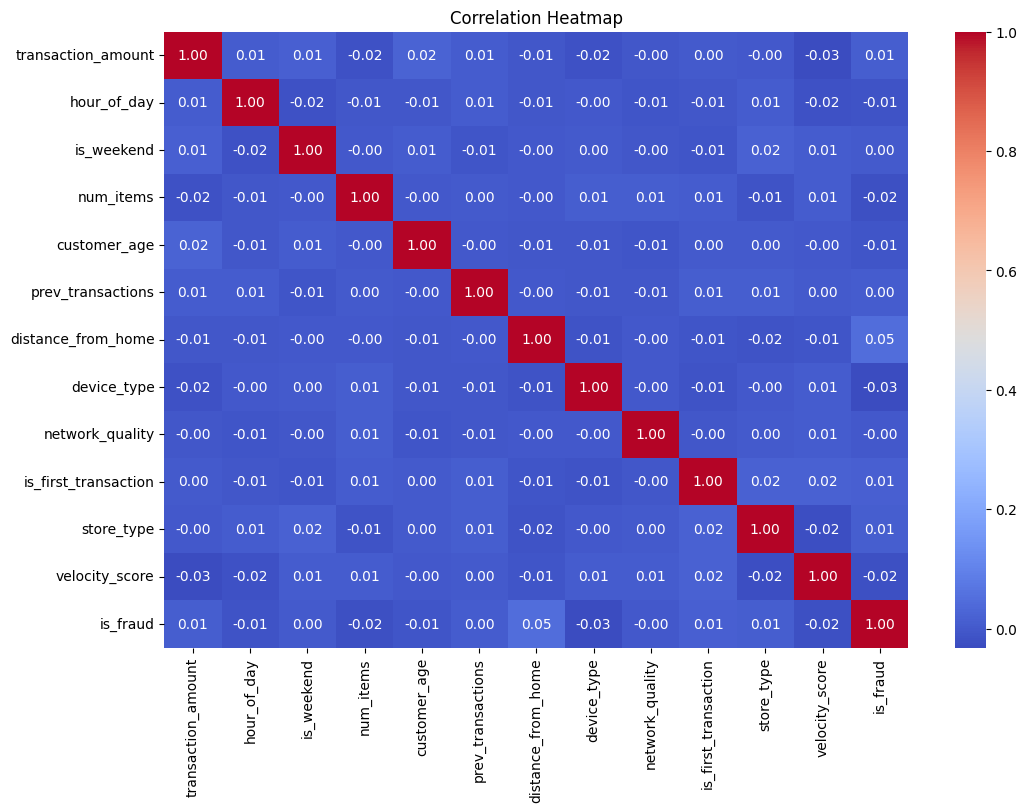

In [72]:
plt.figure(figsize=(12,8))

correlation_matrix = df_clean.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

In [ ]:
# Correlation Heatmap — Analysis

A correlation heatmap was generated to examine relationships between variables and identify potential associations with fraudulent activity.

## Key Observations:
- Most variables show very weak linear correlations with `is_fraud`.
- `distance_from_home` exhibits the strongest positive relationship with fraud, although the correlation remains relatively small.
- No variables demonstrate strong direct linear relationships with fraudulent activity.
- Correlations between independent variables are also very low, suggesting minimal multicollinearity.

## Important Insight:
Fraud detection is often driven by complex behavioral interactions rather than strong individual linear relationships. Weak correlations do not imply that variables are unimportant; instead, fraud patterns may emerge through combinations of multiple behavioral signals.

## Fraud Analytics Learning:
In real-world fraud detection systems:
- fraud patterns are often nonlinear,
- subtle,
- and behavior-driven.

As a result, advanced machine learning models are commonly used to capture interactions between variables that traditional correlation analysis cannot fully detect.

In [73]:
high_amount_threshold = df_clean['transaction_amount'].quantile(0.95)

df_clean['high_amount_flag'] = (
    df_clean['transaction_amount'] > high_amount_threshold
).astype(int)

In [74]:
pd.crosstab(
    df_clean['high_amount_flag'],
    df_clean['is_fraud'],
    normalize='index'
) * 100

is_fraud,0,1
high_amount_flag,,
0,89.654135,10.345865
1,90.571429,9.428571


In [ ]:
# Feature Engineering — High Amount Transaction Flag

A new feature called `high_amount_flag` was created to identify unusually large transactions.

## Method:
Transactions above the 95th percentile of `transaction_amount` were classified as high-value transactions.

- `1` = unusually high transaction amount
- `0` = normal transaction amount

## Purpose:
Feature engineering transforms raw variables into more meaningful behavioral indicators that may improve fraud detection performance.

## Fraud Analytics Learning:
Fraud detection systems often rely on engineered behavioral signals rather than raw transaction values alone. High-value transaction flags can help identify abnormal spending patterns more effectively than continuous transaction amounts in isolation.

In [ ]:
# High Amount Transaction Flag — Analysis

Fraud rates were analyzed for transactions classified as unusually large based on the 95th percentile threshold.

## Fraud Rates:
| High Amount Flag | Fraud Rate (%) |
|---|---|
| 0 (Normal Amount) | 10.35% |
| 1 (High Amount) | 9.43% |

## Key Observations:
- High-value transactions did not exhibit a higher fraud rate.
- Fraud rates were slightly lower among transactions classified as unusually large.
- This suggests that transaction amount alone is not a strong indicator of fraudulent behavior within this dataset.

## Important Insight:
Many legitimate transactions can also involve high spending amounts. Fraud detection often depends on combinations of multiple behavioral signals rather than isolated transaction size.

## Fraud Analytics Learning:
Feature engineering is an iterative process. Not all engineered features produce strong predictive signals, and evaluating feature usefulness is an important part of fraud analytics and machine learning workflows.

In [75]:
far_distance_threshold = df_clean['distance_from_home'].quantile(0.95)

df_clean['far_from_home_flag'] = (
    df_clean['distance_from_home'] > far_distance_threshold
).astype(int)

In [76]:
far_home_fraud_rate = pd.crosstab(
    df_clean['far_from_home_flag'],
    df_clean['is_fraud'],
    normalize='index'
) * 100

far_home_fraud_rate.round(2)

is_fraud,0,1
far_from_home_flag,,
0,89.82,10.18
1,87.43,12.57


In [ ]:
# Far From Home Flag — Analysis

A new behavioral feature called `far_from_home_flag` was created to identify transactions occurring at unusually large geographic distances.

## Method:
Transactions above the 95th percentile of `distance_from_home` were classified as geographically unusual.

- `1` = transaction occurred unusually far from home
- `0` = normal transaction distance

## Fraud Rates:
| Far From Home Flag | Fraud Rate (%) |
|---|---|
| 0 (Normal Distance) | 10.18% |
| 1 (Far Distance) | 12.57% |

## Key Observations:
- Transactions occurring far from home showed a higher fraud rate.
- Geographic anomalies appear to be more informative than transaction amount alone.
- This suggests that unusual location behavior may contribute to fraud risk.

## Important Insight:
Behavioral feature engineering can reveal stronger fraud signals than raw variables alone.

## Fraud Analytics Learning:
Fraud detection systems frequently use geographic anomaly indicators because fraudulent transactions often occur outside a customer’s normal location patterns.

In [77]:
df_clean['high_risk_behavior'] = (
    (df_clean['far_from_home_flag'] == 1) &
    (df_clean['is_first_transaction'] == 1)
).astype(int)

In [78]:
risk_behavior_rate = pd.crosstab(
    df_clean['high_risk_behavior'],
    df_clean['is_fraud'],
    normalize='index'
) * 100

risk_behavior_rate.round(2)

is_fraud,0,1
high_risk_behavior,,
0,89.72,10.28
1,86.11,13.89


In [ ]:
# Combined Behavioral Risk Feature — Analysis

A combined behavioral feature called `high_risk_behavior` was created by combining two suspicious transaction conditions:

- transaction occurred unusually far from home
- transaction was marked as a first transaction

## Logic:
| Condition | Value |
|---|---|
| Both conditions true | 1 |
| Otherwise | 0 |

## Fraud Rates:
| High Risk Behavior | Fraud Rate (%) |
|---|---|
| 0 | 10.28% |
| 1 | 13.89% |

## Key Observations:
- Transactions exhibiting both suspicious behaviors showed a noticeably higher fraud rate.
- Combining behavioral indicators produced a stronger fraud signal than individual variables alone.
- This demonstrates the importance of feature interaction analysis in fraud detection.

## Important Insight:
Fraud detection systems often rely on layered behavioral signals rather than isolated variables.

## Fraud Analytics Learning:
Behavioral feature engineering is a critical component of fraud analytics because fraudulent activity frequently emerges through combinations of abnormal transaction patterns.

In [79]:
X = df_clean.drop('is_fraud', axis=1)

y = df_clean['is_fraud']

In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [81]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5600, 15)
(1400, 15)
(5600,)
(1400,)


In [ ]:
# Machine Learning Preparation

The dataset was prepared for machine learning by separating input features (`X`) from the target variable (`y`).

## Features (`X`)
Input variables used for fraud prediction, including:
- original transaction variables,
- cleaned variables,
- and engineered behavioral features.

## Target (`y`)
The target variable:
- `0` = legitimate transaction
- `1` = fraudulent transaction

## Train-Test Split
The dataset was divided into:
- 80% training data
- 20% testing data

A stratified split was used to preserve the original fraud distribution across both datasets due to class imbalance.

## Important Machine Learning Practice
Separating training and testing data helps evaluate model performance on unseen transactions and reduces the risk of overfitting.

In [83]:
from sklearn.linear_model import LogisticRegression

# Initialize model
log_model = LogisticRegression(max_iter=1000)

# Train model
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [84]:
y_pred = log_model.predict(X_test)

In [ ]:
# Logistic Regression Model Training

A Logistic Regression model was selected as the first baseline machine learning algorithm for fraud prediction.

## Why Logistic Regression?
Logistic Regression is widely used in:
- fraud analytics,
- banking risk systems,
- and binary classification problems.

It is:
- simple,
- interpretable,
- computationally efficient,
- and useful as a baseline fraud detection model.

## Model Training Process
The model was trained using:
- `X_train` → input features
- `y_train` → fraud labels

The trained model learned relationships between transaction behavior patterns and fraudulent activity.

## Prediction Generation
After training, predictions were generated on unseen testing data using:

```python
y_pred = log_model.predict(X_test)

In [85]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))

Accuracy: 0.8971


In [86]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      1256
           1       0.00      0.00      0.00       144

    accuracy                           0.90      1400
   macro avg       0.45      0.50      0.47      1400
weighted avg       0.80      0.90      0.85      1400



/Users/aksharpastagia/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/aksharpastagia/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/aksharpastagia/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

In [ ]:
# Logistic Regression Evaluation — Initial Results

The Logistic Regression model achieved approximately 90% accuracy on the testing dataset. However, deeper evaluation revealed that the model failed to correctly identify fraudulent transactions.

## Key Findings:
- The model predicted nearly all transactions as legitimate (`0`).
- Fraud recall for class `1` was 0.00, meaning no fraudulent transactions were successfully detected.
- Precision and F1-score for the fraud class were also 0.00.

## Important Insight:
Although overall accuracy appeared high, the model performance was misleading due to severe class imbalance in the dataset.

Because legitimate transactions represent approximately 90% of the data, a model that predicts all transactions as legitimate can still achieve high accuracy while completely failing at fraud detection.

## Fraud Analytics Learning:
In fraud detection problems:
- accuracy alone is not a reliable evaluation metric,
- recall and precision are significantly more important,
- especially for identifying rare fraudulent events.

## Business Interpretation:
A model that fails to detect fraud would be unacceptable in real-world banking systems because fraudulent transactions would pass through undetected.

In [89]:
y_pred_balanced = balanced_log_model.predict(X_test)

/Users/aksharpastagia/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

In [90]:
print(classification_report(y_test, y_pred_balanced))

/Users/aksharpastagia/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
# Logistic Regression Convergence Warning

During training of the balanced Logistic Regression model, a convergence warning was generated indicating that the optimization algorithm reached the maximum iteration limit before fully converging.

## Important Clarification:
The model still trained successfully. This warning does not indicate model failure.

## Possible Causes:
- Variables exist on very different numerical scales.
- Logistic Regression optimization becomes slower when features are unscaled.
- Fraud datasets often contain heterogeneous feature ranges and engineered variables.

## Professional Machine Learning Insight:
Feature scaling is commonly applied before Logistic Regression to improve optimization stability and convergence performance.

## Fraud Analytics Learning:
Different machine learning algorithms respond differently to feature scaling:
- Logistic Regression often benefits from scaling.
- Tree-based models such as Random Forest and XGBoost generally do not require feature scaling.

In [ ]:
# Balanced Logistic Regression — Evaluation Results

After applying class balancing, the Logistic Regression model showed significant improvement in fraud detection performance.

## Model Performance:
| Metric | Fraud Class (`1`) |
|---|---|
| Precision | 0.11 |
| Recall | 0.47 |
| F1-score | 0.18 |

## Key Observations:
- Fraud recall improved substantially from 0.00 to 0.47.
- The model successfully detected approximately 47% of fraudulent transactions.
- Overall accuracy decreased from ~90% to ~56%.

## Important Insight:
The decrease in accuracy reflects a common fraud detection tradeoff:
- improved fraud detection often increases false positives,
- while maximizing accuracy can lead to fraud being ignored entirely.

## Fraud Analytics Learning:
In imbalanced fraud datasets:
- recall is often more important than raw accuracy,
- especially because missing fraudulent transactions can create significant financial risk.

## Business Interpretation:
The balanced model became more aggressive in identifying suspicious transactions, improving fraud detection capability at the cost of incorrectly flagging more legitimate transactions.

In [91]:
from sklearn.model_selection import train_test_split

# Features
X = df_clean.drop('is_fraud', axis=1)

# Target
y = df_clean['is_fraud']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [92]:
from sklearn.linear_model import LogisticRegression

balanced_log_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

balanced_log_model.fit(X_train, y_train)

/Users/aksharpastagia/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

In [93]:
y_pred_balanced = balanced_log_model.predict(X_test)

In [94]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_balanced))

cm_balanced = confusion_matrix(y_test, y_pred_balanced)
print(cm_balanced)

              precision    recall  f1-score   support

           0       0.91      0.57      0.70      1256
           1       0.12      0.51      0.20       144

    accuracy                           0.56      1400
   macro avg       0.52      0.54      0.45      1400
weighted avg       0.83      0.56      0.65      1400

[[716 540]
 [ 70  74]]


In [ ]:
# Balanced Logistic Regression — Final Evaluation

The balanced Logistic Regression model significantly improved fraud detection capability compared to the original baseline model.

## Confusion Matrix Interpretation

| Actual / Predicted | Legit (`0`) | Fraud (`1`) |
|---|---|---|
| Legit (`0`) | 716 | 540 |
| Fraud (`1`) | 70 | 74 |

## Key Findings
- The model successfully detected 74 fraudulent transactions.
- Fraud recall improved to approximately 51%.
- However, the model also generated a large number of false positives (540 legitimate transactions incorrectly flagged as fraud).

## Business Interpretation
The balanced model became more aggressive in identifying suspicious activity:
- improving fraud detection,
- while increasing customer friction due to false alerts.

## Important Fraud Analytics Insight
Fraud detection systems operate on a precision-recall tradeoff:
- increasing fraud recall often increases false positives,
- while reducing false positives may allow fraud to go undetected.

## Professional Assessment
Although the balanced Logistic Regression model improved fraud detection performance, overall predictive quality remains limited due to the complexity and nonlinear nature of fraudulent behavior patterns.